# Notebook 06 — The Transfer-Gap Story

**Purpose**: a fast, live, artifact-grounded demo of this project's central scientific finding — a strong public-dataset (Olist) research result does not transfer to HASEBHA's real single-vendor architecture, quantified and independently re-confirmed — plus the funnel enrichment negative result (NR-16) tested as a further honest check for any untapped public signal.

**Design constraint**: this notebook only *reads* saved parquet/CSV/JSON artifacts and computes fast univariate statistics live. No retraining, no heavy compute. Expected end-to-end runtime: well under 2 minutes.

Every number displayed below is either read directly from a saved artifact, or recomputed live from raw data in front of you — never hardcoded from memory.

## 1. Prove the data is real: live univariate spot-check

Before trusting any headline number, recompute a handful of feature-level AUCs directly from the raw canonical parquet, live, in front of the audience — the same spot-check this project's own author and an independent auditor both performed before trusting the forensic study.

In [1]:
import time
t0 = time.time()

import json
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
ART_V3 = ROOT / "artifacts/experiments/olist_v3_multistage"
REPORTS_V3 = ROOT / "reports/generated/olist_v3_multistage"

df = pd.read_parquet(ART_V3 / "seller_sla_canonical.parquet").sort_values("order_purchase_timestamp").reset_index(drop=True)
y = df["SELLER_HANDOFF_SLA_BREACH"].values
print(f"Loaded canonical cohort: {df.shape[0]:,} rows, {df.shape[1]} columns")

spot_check_features = ["total_price", "same_state", "seller_past_breach_rate_expanding", "days_to_shipping_deadline"]
live_auc = {}
for c in spot_check_features:
    x = df[c].values
    live_auc[c] = roc_auc_score(y, x)

# reference values from the forensic study's saved results, for direct comparison
forensic = json.loads((REPORTS_V3 / "forensics/FORENSIC_EXPERIMENT_RESULTS.json").read_text())
reference_auc = forensic["_univariate_auc"]

print(f"{'feature':<38}{'live (recomputed now)':<24}{'saved artifact':<18}{'match?'}")
for c in spot_check_features:
    ref = reference_auc[c]["auc"]
    match = abs(live_auc[c] - ref) < 1e-9
    print(f"{c:<38}{live_auc[c]:<24.16f}{ref:<18.16f}{'EXACT MATCH' if match else 'MISMATCH -- STOP'}")
    assert match, f"STOP: {c} does not match the saved artifact -- do not trust downstream numbers"

print(f"\nAll {len(spot_check_features)} spot-checked features match the saved forensic artifact bit-for-bit.")
print(f"[{time.time()-t0:.1f}s elapsed]")

Loaded canonical cohort: 96,380 rows, 27 columns
feature                               live (recomputed now)   saved artifact    match?
total_price                           0.5367201912543373      0.5367201912543373EXACT MATCH
same_state                            0.5015424943519140      0.5015424943519140EXACT MATCH
seller_past_breach_rate_expanding     0.7291471073066506      0.7291471073066506EXACT MATCH
days_to_shipping_deadline             0.4825794671812899      0.4825794671812899EXACT MATCH

All 4 spot-checked features match the saved forensic artifact bit-for-bit.
[11.2s elapsed]


## 2. The forensic ablation: where the 0.77 → 0.55 collapse comes from

All numbers below are read directly from `reports/generated/olist_v3_multistage/forensics/FORENSIC_EXPERIMENT_RESULTS.json` — the same independently-executed forensic study spot-checked in Section 1 — no retraining happens in this notebook.

Feature set                                    Mean AUC    Worst-period AUC
FULL-23 (frozen research)                        0.7686              0.6685
Seller-history ONLY (8 feats)                    0.7568              0.6430
P + deadline + installments (no seller hist)     0.5666              0.5313
MODEL P (13 features)                            0.5540              0.5270

Total collapse (FULL-23 -> MODEL P): 0.2146 AUC
Share of collapse attributable to removing seller-history alone: 94.1%


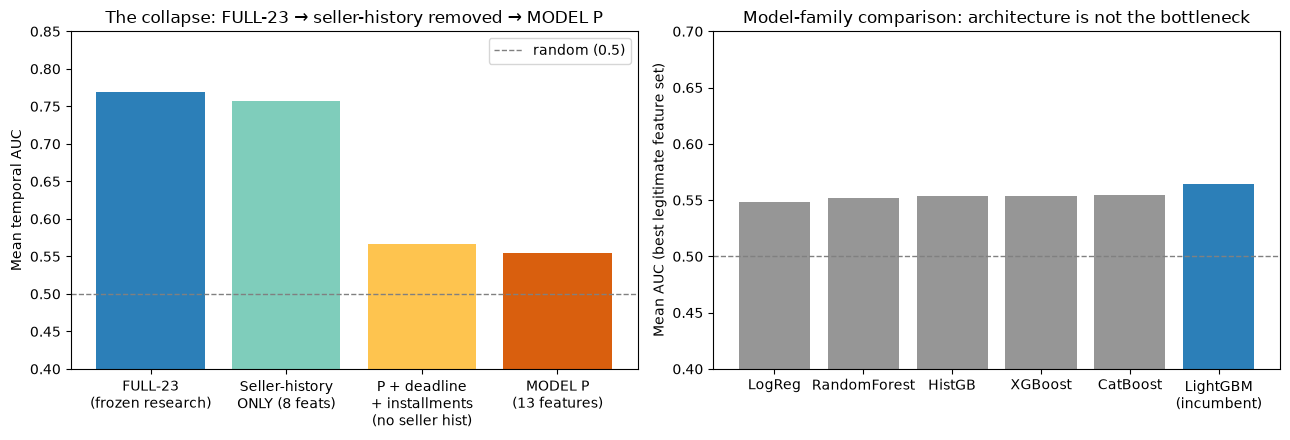


[12.6s elapsed]


In [2]:
import matplotlib.pyplot as plt

ablation_order = ["AB_FULL_23", "AB_SELLER_HIST_ONLY", "AB_NO_SELLER_HIST", "P_BASELINE_REPRO"]
ablation_labels = ["FULL-23\n(frozen research)", "Seller-history\nONLY (8 feats)", "P + deadline\n+ installments\n(no seller hist)", "MODEL P\n(13 features)"]
ablation_means = [forensic[k]["mean_auc"] for k in ablation_order]

print(f"{'Feature set':<45}{'Mean AUC':>10}{'Worst-period AUC':>20}")
for k, lbl in zip(ablation_order, ["FULL-23 (frozen research)", "Seller-history ONLY (8 feats)", "P + deadline + installments (no seller hist)", "MODEL P (13 features)"]):
    print(f"{lbl:<45}{forensic[k]['mean_auc']:>10.4f}{forensic[k]['worst_auc']:>20.4f}")

collapse = forensic["AB_FULL_23"]["mean_auc"] - forensic["P_BASELINE_REPRO"]["mean_auc"]
seller_hist_share = (forensic["AB_FULL_23"]["mean_auc"] - forensic["AB_NO_SELLER_HIST"]["mean_auc"]) / collapse
print(f"\nTotal collapse (FULL-23 -> MODEL P): {collapse:.4f} AUC")
print(f"Share of collapse attributable to removing seller-history alone: {seller_hist_share:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(ablation_labels, ablation_means, color=["#2c7fb8", "#7fcdbb", "#fec44f", "#d95f0e"])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="random (0.5)")
axes[0].set_ylabel("Mean temporal AUC")
axes[0].set_title("The collapse: FULL-23 → seller-history removed → MODEL P")
axes[0].set_ylim(0.4, 0.85)
axes[0].legend()

families = ["logreg", "rf", "histgb", "xgb", "catboost", "lgbm"]
family_labels = ["LogReg", "RandomForest", "HistGB", "XGBoost", "CatBoost", "LightGBM\n(incumbent)"]
family_auc = [forensic["_model_family_P_ALLNUM"][f]["mean_auc"] if f != "lgbm" else forensic["P_ALL"]["mean_auc"] for f in families]
axes[1].bar(family_labels, family_auc, color=["#969696"] * 5 + ["#2c7fb8"])
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].set_ylabel("Mean AUC (best legitimate feature set)")
axes[1].set_title("Model-family comparison: architecture is not the bottleneck")
axes[1].set_ylim(0.4, 0.7)

plt.tight_layout()
plt.show()
print(f"\n[{time.time()-t0:.1f}s elapsed]")

## 3. Did we leave any public signal untapped? The Marketing Funnel test (NR-16)

Reads the two raw funnel CSVs plus the saved audit/experiment JSONs — all numbers below are read live, not hardcoded from this notebook's own memory of the mission.

In [3]:
FUNNEL_RAW = ROOT / "data/raw/olist_funnel"
FUNNEL_REPORTS = ROOT / "reports/generated/olist_funnel"

mql = pd.read_csv(FUNNEL_RAW / "olist_marketing_qualified_leads_dataset.csv")
cd = pd.read_csv(FUNNEL_RAW / "olist_closed_deals_dataset.csv")
print(f"MQL leads: {len(mql):,} rows | Closed deals: {len(cd):,} rows")

audit = json.loads((FUNNEL_REPORTS / "FUNNEL_DATA_QUALITY_AUDIT.json").read_text())
cov = audit["join_coverage_against_canonical_cohort"]
rev = audit["declared_monthly_revenue_reliability_audit"]

print(f"\nSeller overlap with canonical cohort: {cov['overlap_sellers']} / {cov['canonical_n_unique_sellers']} sellers ({cov['overlap_pct_of_canonical_sellers']:.1%})")
print(f"Canonical rows with a funnel-covered seller: {cov['canonical_rows_with_funnel_covered_seller']:,} / {cov['canonical_n_rows']:,} ({cov['canonical_rows_coverage_pct']:.1%})")
print(f"declared_monthly_revenue exactly zero: {rev['n_zero']} / {rev['n']} rows ({rev['pct_zero']:.1%}) -- excluded as unreliable")

exp = json.loads((FUNNEL_REPORTS / "FUNNEL_EXPERIMENT_RESULTS.json").read_text())
print(f"\nPredeclared hypothesis: {exp['predeclared_hypothesis']}")
print(f"Baseline (FULL-23, reproduced): {exp['baseline']['mean_auc']:.4f} mean AUC")
print(f"Treatment (FULL-23 + funnel):   {exp['treatment']['mean_auc']:.4f} mean AUC")
print(f"Delta: {exp['mean_auc_delta']:+.4f}  <-- small NEGATIVE, not the predeclared positive range")

print("\nFunnel-only univariate AUCs (all ~0.50 = no signal):")
for feat, v in exp["funnel_only_univariate_auc"].items():
    print(f"  {feat:<35} {v['auc']:.4f}")

print(f"\n[{time.time()-t0:.1f}s elapsed]")

MQL leads: 8,000 rows | Closed deals: 842 rows

Seller overlap with canonical cohort: 377 / 2955 sellers (12.8%)
Canonical rows with a funnel-covered seller: 4,384 / 96,380 (4.5%)
declared_monthly_revenue exactly zero: 797 / 842 rows (94.7%) -- excluded as unreliable

Predeclared hypothesis: small gain, +0.01 to +0.03 mean AUC vs FULL-23 baseline; zero or negative is a legitimate, honestly-reported result
Baseline (FULL-23, reproduced): 0.7692 mean AUC
Treatment (FULL-23 + funnel):   0.7658 mean AUC
Delta: -0.0034  <-- small NEGATIVE, not the predeclared positive range

Funnel-only univariate AUCs (all ~0.50 = no signal):
  seller_history_available_funnel     0.4977
  seller_tenure_days                  0.4979
  time_to_close_days                  0.4977
  origin                              0.4979
  lead_type                           0.4979
  business_segment                    0.4978

[12.7s elapsed]


## 4. The single most defensible sentence

Pulled verbatim from `docs/committee/D5_COMMITTEE_QA_BRIEF.md`, Question 15:

> "We built and rigorously validated several strong research/production models on public and recommendation data, and for the one capability where we tested transfer to our real production environment, we proved — quantitatively, not by assumption — that the public-data signal does not survive real feature-availability constraints, and we specified exactly what data and business decision are needed to close that gap."

---
*End of notebook. Total runtime printed above each section for the demo timer.*